# Worksheet 4.2 - Action-Value Control with Linear State Approximation 

**Learning outcomes**

1. **Apply** tabular control methods to function approximation settings
2. **Apply** tabular policy methods to policy approximation settings
3. **Use** tile coding for continuous control problems
4. **Distinguish** between additive and multiplicative state representations
5. **Derive** Binary Sarsa by exploiting binary state encoding
6. **Evaluate** the benefit of hashing with tile coding, including index hash tables

In this worksheet, we extend function approximation to **control**, using tile coding on a 
continuous state space — specifically, an underpowered car that must climb a mountain. We 
present progressively richer representations: single-tiling (discretisation) and multi-tiling 
(offset tilings) hashed tile coding.

In subsequent lessons, we move to eligibility traces, then to policy gradient methods.

## Benchmark Control Problems

In this and the coming worksheets, we tackle one or more of the following continuous control 
problems. **CartPole** is a fully actuated balancing task included as a baseline — its dense 
rewards and intuitive optimal behaviour make it a good sanity check for any new algorithm. 
The remaining three — **MountainCar**, **Acrobot**, and **Pendulum** — are classical 
underactuated problems where the agent cannot move directly toward the goal and must instead 
exploit the system's dynamics to build momentum. All four require function approximation due 
to their continuous state spaces, and all reward long-horizon planning over greedy immediate 
behaviour.

## Mountain Car

A car is stuck at the bottom of a valley between two hills. The right hilltop is the goal, 
but the car's engine is too weak to climb directly. The agent must learn to swing back and 
forth to build momentum before committing to a final forward push — an unintuitive strategy 
that makes this a challenging exploration problem.

The state space is **2D**: position $x \in [-1.2,\ 0.5]$ and velocity $\dot{x} \in 
[-0.07,\ 0.07]$. The agent has three discrete actions: push left, do nothing, push right. 
Rewards are **sparse** — $-1$ at every step until the goal is reached, up to a maximum of 
200 steps per episode. We will use discretised and tile-coded representations in studying 
this problem.

## Acrobot

Acrobot is a two-link robotic arm hanging downward, controlled at the joint between the two 
links. The goal is to swing the tip of the lower link above a target height. Like MountainCar, 
the agent cannot simply apply force toward the goal — it must swing the arm downward first 
to build angular momentum before swinging up.

The state space is **6D**: the cosine and sine of each joint angle, and the angular velocity 
of each link. The agent has three discrete actions: apply negative torque, no torque, positive 
torque. Rewards are **sparse** — $-1$ per step until the tip reaches the target height, up 
to 500 steps per episode. The higher dimensionality makes tabular methods impractical, 
motivating the use of tile coding.

## Pendulum

A pendulum starts in a random position and must be swung up and balanced at the upright 
position. Unlike MountainCar and Acrobot, the agent applies **continuous torque** 
$\tau \in [-2,\ 2]$, making this a continuous action problem.

The state space is **3D**: $\cos\theta$, $\sin\theta$, and angular velocity $\dot{\theta}$. 
Rewards are **dense** and shaped — the agent is penalised for the angle from upright, angular 
velocity, and torque magnitude, making learning easier but precise optimisation harder. 
The continuous action space motivates the use of policy gradient methods such as Actor-Critic.

## CartPole

A pole is attached to a cart moving along a frictionless track. The agent controls the cart 
by pushing it left or right, with the goal of keeping the pole balanced upright for as long 
as possible. Unlike the underactuated problems below, the agent has direct control authority 
— no counterintuitive strategy is needed, just fast reactive control.

The state space is **4D**: cart position, cart velocity, pole angle, and pole angular 
velocity. The agent has two discrete actions: push left or push right. Rewards are **dense** 
— $+1$ at every step the pole remains upright, up to 500 steps per episode.

Although CartPole is dynamically simpler than MountainCar, its 4D state space makes 
discretisation significantly more expensive — a grid of $(8 \times 8 \times 20 \times 20) = 
25{,}600$ bins compared to MountainCar's $18 \times 14 = 252$. This illustrates the 
**curse of dimensionality**: representational complexity grows multiplicatively with the 
number of state dimensions, making tile coding and hashing essential for higher-dimensional 
problems.

Let's get started.

In [1]:
# %cd ~/rl_rob 
# !git pull

In [2]:
%matplotlib inline

In [3]:
from rl.linear import *
# from math import floor

Note that we imported the Grid and the other environments from the Function approximation lesson because we are dealing with vectorised environment form now on.

## MDP with Linear Function Approximation

By assigning `self.Q = self.Q_`, we make `self.Q` a callable, preserving the same update 
structure used in the tabular case — so `self.Q(s, a)` works exactly as before.

> **`vMDP`** extends `vMRP` with control capability using an $\varepsilon$-greedy policy. 
> Instead of a Q-table, it maintains a weight matrix $W \in \mathbb{R}^{n_A \times n_F}$, 
> computing action values as $Q(s, a) = \mathbf{w}_a^\top \mathbf{x}(s)$ — one weight vector 
> per action. The gradient $\Delta Q(s) = \mathbf{x}(s)$ drives the weight updates during learning.

Below we make sure that the classes hierarchy is correct by double-checking that the policy of an MDP object is εgreedy.

In [4]:
vMDP().policy

<bound method MDP.<locals>.MDP.εgreedy of <rl.linear.vMDP object at 0x11109b4d0>>

## Offline MCC with Any Function Approximation

In [5]:
class vMCC(vMDP):

    def init(self):
        self.store = True
        
    # ---------------------------- 🌘 offline, MC learning: end-of-episode learning-----------------------    
    def offline(self):  
        # obtain the return for the latest episode
        Gt = 0
        for t in range(self.t, -1, -1):
            s = self.s[t]
            a = self.a[t]
            rn = self.r[t+1]
            
            Gt = self.γ*Gt + rn
            self.W[a] += self.α*(Gt - self.Q(s,a))*self.ΔQ(s)

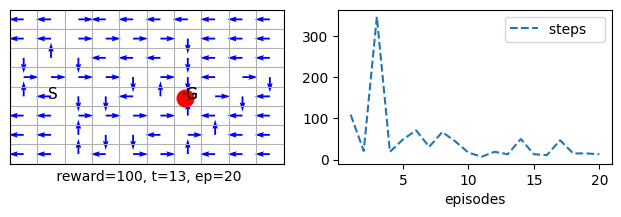

In [6]:
vmc = vMCC(env=vgrid(reward='reward100'), α=.5, episodes=20, seed=10, **demoQ).interact()

## Online Sarsa with Any Function Approximation

In [10]:
class vSarsa(vMDP):

    def init(self): #α=.8
        self.step = self.step_an # for Sarsa we want to decide the next action in time step t

    # ----------------------------------------🌖 online learning ----------------------------------------
    def online(self, s, rn,sn, done, a,an):
        self.W[a] += self.α*(rn + (1-done)*self.γ*self.Q(sn,an) - self.Q(s,a))*self.ΔQ(s)
 

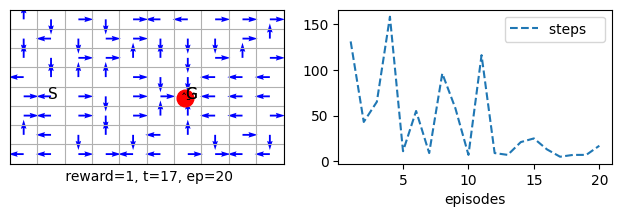

In [12]:
vsarsa = vSarsa(env=vgrid(reward='reward1'), α=.8, episodes=20, seed=10, **demoQ).interact()

In [19]:
vsarsa.Q()[1:10,:].round(1)

array([[-2.9, -3.3, -3.5, -3.3],
       [-3.1, -2.7, -3.1, -3.5],
       [-3.1, -1.9, -2.5, -2.4],
       [-1.6, -1.6, -1.8, -1.6],
       [-1.4, -1.6, -1.6, -1.6],
       [-1.6, -1. , -1.8, -1.1],
       [-1.4,  0. ,  0. , -0.8],
       [ 0. ,  0. , -0.8, -0.8],
       [ 0. ,  0. ,  0. ,  0. ]])

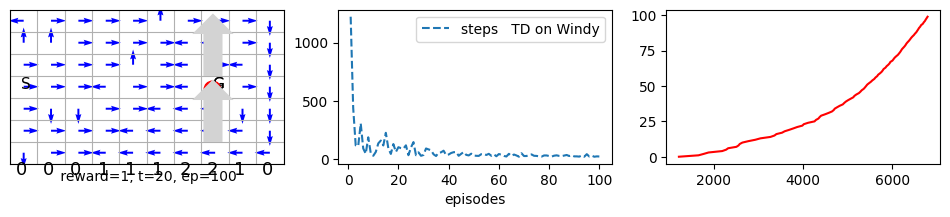

In [23]:
def example_6_5():
    return vSarsa(env=vwindy(reward='reward1'), α=.5, episodes=100, seed=100, **demoQ).interact(label='TD on Windy')
    
trainedV = example_6_5()

plt.subplot(133).plot(trainedV.Ts.cumsum(), range(trainedV.episodes),'-r', label='cumulative steps')
plt.show()

## Q-learning with Function Approximation

In [24]:
class vQlearn(vMDP):
    # ---------------------------- 🌖 online control learning 🕹️ ----------------------------
    def online(self, s, rn,sn, done, a,_):
        self.W[a] += self.α*(rn + (1-done)*self.γ*self.Q(sn).max() - self.Q(s,a))*self.ΔQ(s)

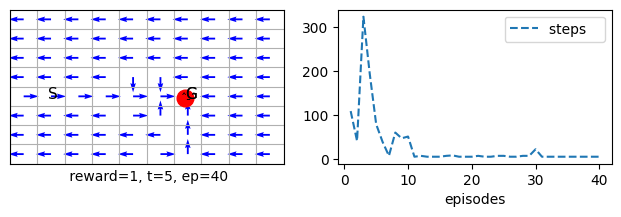

In [25]:
vqlearn = vQlearn(env=vgrid(), α=.8, γ=1, episodes=40, seed=10, **demoQ).interact()

## Sarsa and Q-Learning on the Cliff!

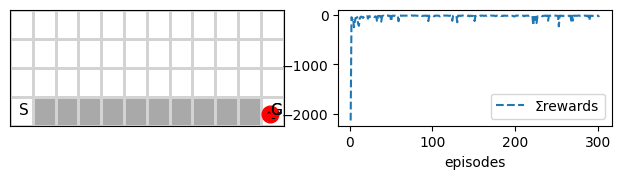

In [26]:
vsarsa = vSarsa(env=vcliffwalk(), α=.5, episodes=100, seed=10, **demoR).interact()

100%|██████████████████████████████████████████████████████████████████████████████████████████|20/20
100%|██████████████████████████████████████████████████████████████████████████████████████████|20/20


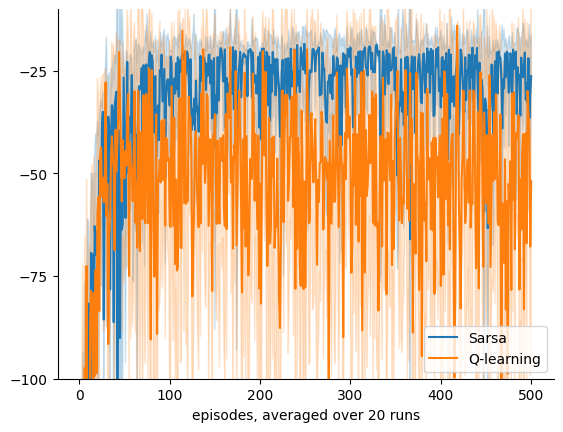

In [28]:
vSarsaCliff, vQlearnCliff = example_6_6(runs=100, env=vcliffwalk(), alg1=vSarsa, alg2=vQlearn)# runs=500

In [29]:
class vXSarsa(vMDP):
     # ---------------------------- 🌖 online control learning 🕹️ ----------------------------
    def online(self, s, rn,sn, done, a,_):      
        # obtain the ε-greedy policy probabilities, then obtain the expectation via @ for efficiency
        v = self.Q(sn)@self.π(sn)
        self.W[a] += self.α*(rn + (1-done)*self.γ*v - self.Q(s,a))*self.ΔQ(s)

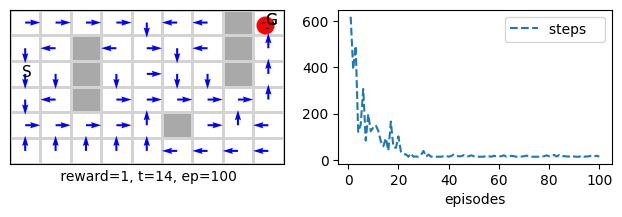

In [30]:
vxsarsa = vXSarsa(env=vmaze(), α=.5, γ=1, episodes=100, seed=1, **demoQ).interact()

##  One-hot-encoding with redundant features for control

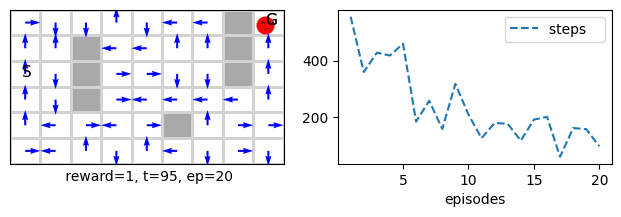

In [5]:
vsarsa = vSarsa(env=vmaze(nF=160, reward='reward1'), episodes=20, seed=10, **demoQ)
vsarsa.store=True
vsarsa.interact()

In [6]:
vsarsa.s[0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint32)

Note how we have almost 100 extra redundant features that will never be turned on. The point of doing such thing is to double check that our infrastructure is capable of accommodating different features sizes and is not tied to a feature representation that has the same size of the state space.

## Continuous Problem and State Space Discretisation

We begin by discretising each dimension into $n_{bins}$ equal intervals of width $\omega$. 
Below we visualise the position boundaries and some intermediate values. Note that the goal 
state always corresponds to index $n_{tiles}$, giving $n_{tiles} + 1$ states in total.

> **`GymDiscretised`** wraps a Gym environment with discretisation. It clips each observation 
> dimension to its range, divides it into $n_{bins}$ equal bins, and returns a one-hot feature 
> vector $\mathbf{x}(s) \in \mathbb{R}^{\prod n_{bins}}$ from each `reset()` and `step()` 
> call — one component per discrete state.

## Additive State Representation

Since the car's state is defined by two continuous dimensions, we need to combine their 
discretisations. We start with an **additive** representation — concatenating the one-hot 
vector for position ($n_{tiles}$ components) with the one-hot vector for velocity ($n_{tiles}$ 
components), giving a feature vector of size $2 \times n_{tiles}$ with exactly **2 active 
components** at any time. This is sometimes called a *2-hot* encoding.

This additive approach serves as a stepping stone toward tile coding, helping us appreciate 
why the multiplicative (tiled) representation is more powerful.

In [1]:
from env.gym.base import *

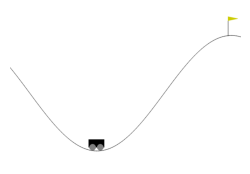

In [27]:
mcar = Gym(**MountainCar)
obs = play(mcar, 100)

## Studying the Behaviour of the Car

First, let us observe what happens with no throttle — the car oscillates back and forth under 
gravity alone, unable to escape the valley.

### A Working Solution

The car's engine is too weak to climb directly. A working strategy is to first build momentum 
by swinging back and forth before committing to a final forward push:

1. Accelerate **forward** to gain speed
2. Accelerate **backward** to swing back and build momentum  
3. Full throttle **forward** to reach the goal

Try reducing `swing` below 22 to see the car fail to reach the top — this gives an intuition 
for why a naive greedy policy is insufficient and why the agent must learn to plan ahead.

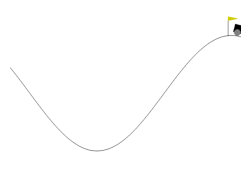

In [9]:
mcar.reset()

# swing forward and backward to gain momentum and then go full speed on
swing=24 # try 22 or less to see what happen
# 1. accelerate forward  
for _ in range(swing):
    mcar.step(2)
    mcar.render()
    
# 2. accelerate backward to take advantage from the momentum
for _ in range(swing):
    mcar.step(0)
    mcar.render()

# 3. now full throttle forward to reach the goal
for _ in range(100):
    mcar.step(2)
    mcar.render()

### Why This Problem is Hard

What makes this particularly challenging is that the agent must temporarily move **away** from 
the goal to eventually reach it — things must get worse before they get better. Credit 
assignment therefore operates on a long horizon rather than on immediate improvements, making 
this a poor fit for traditional control algorithms and an ideal testbed for RL.

The RL agent must discover a policy similar to the hand-crafted solution above — but 
automatically, through interaction with the environment alone. We approach this in two stages: 
first using a discretised (additive) representation, then tile coding (multiplicative).



> **Note:** during the experiments below we may set $\alpha = (\cdot)/8$ directly since the default 
> number of tiles per dimension is 8. Do not confuse this with the number of tilings 
> $n_{tilings}$, which we will vary but may also be set to 8.

## Discretised State Representation (Additive)

We discretise each dimension independently and **concatenate** the resulting one-hot vectors, 
giving a feature vector of size $2 \times n_{tiles}$ with exactly **2 active components** — 
one for position, one for velocity. This additive representation is simple but does not 
capture the interaction between the two dimensions.

Let us start training.

First, we will use the following dictionary for Gym to train and visualise the different Gym environments.

In [10]:
demoGym = {'plotT':True, 'plotR':True, 'visual':True, 'animate':True}     # suitable for games

In [1]:
from env.gym.discretised import *
from rl.linear import *

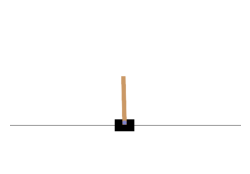

[-0.01905574 -0.0465871  -0.02879695  0.04782595]


In [2]:
cart = Gym(**CartPole)
cart.reset()
cart.render()
print(cart.s_())

Let us see the discretised version of the mountain car, where each continuous state is turned into an index.

In [3]:
cart_discret = GymDiscretised(**CartPole)
cart_discret.reset()
cart_discret.s_()

292

Let us now see the vectorised form of this discritised environment that use one-hot encoding similar to how we did for vGrid, where we turn on the component corresponding to the state (index).

In [4]:
vcart_discret = vGymDiscretised(**CartPole)
vcart_discret.reset()
vcart_discret.s_().shape

(648,)

## Training a Vectroised Discretised Gym Environment

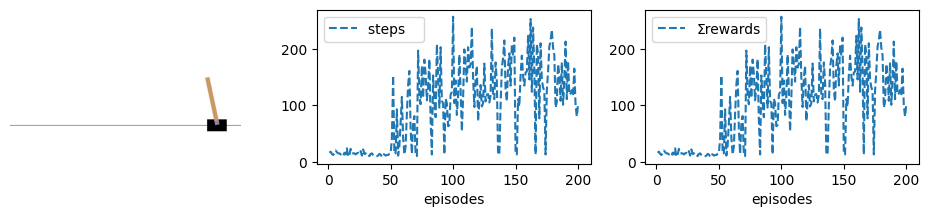

In [19]:
vsarsa = vSarsa(env=vcart_discret, α=.7/1, γ=0.99, ε=0.1,  εT=2e4, εmin=0, max_t=int(5e3), episodes=200, seed=0, **demoGym).interact()

In [15]:
vsarsa.t_
vsarsa.ε

0

Note that for CartPole, **more steps per episode is better** — unlike MountainCar where fewer 
steps means a faster solution, here the agent is rewarded for surviving as long as possible.

We divide $\alpha$ by 1 since only one feature is active at any time — consistent with the 
one-hot encoding used in discretisation.

Note that the random starting position introduces an uncontrollable source of variability — 
even with the same seed, learning curves will differ across runs.

This is a genuinely harder problem for discretised methods — the optimal policy requires 
precise continuous control that coarse bins struggle to represent. Do not be discouraged by 
modest results here. Try different algorithms, hyperparameters, and longer episodes to see 
how far you can push discretisation. Significantly better results should be expected when we 
move to tile coding, which captures the continuous nature of the state space more faithfully.

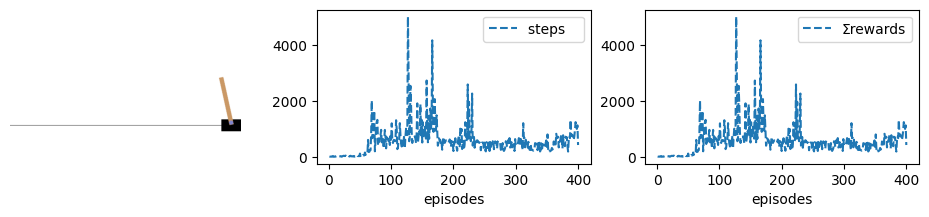

In [18]:
cart_tiled = GymTiled(**CartPole)
n_tilings = CartPole['n_tilings']
sarsa = vSarsa(env=cart_tiled, α=.4/n_tilings, episodes=400, seed=0, ε=.1, εT=2e4, εmin=0, max_t=int(5e3), **demoGym).interact()

Let us check the density of the cartpole rewards. If we recieves a reward >0 at the start then that means rewards are not sparse and they are dense. The following shows that the rewrds for cartpol is indeed dense.

In [23]:
cart = Gym(**CartPole)
cart.reset()
s, r, terminated, truncated, info = cart.step(1)
print(r)

1.0


Let us check for MountainCar

In [26]:
car = Gym(**MountainCar)
car.reset()
s, r, terminated, truncated, info = car.step(1)
print(r)

-1.0


### Exploration by Optimistic Initialisation

We use a reward of $-1$ at every step with an initial value estimate of $0$. These initial 
values are **optimistic** — since the agent will be penalised at every step before reaching 
the goal, it will consistently be disappointed by the rewards it receives. This disappointment 
naturally drives exploration in the early episodes, so we do not need an explicit exploratory 
policy and can set $\varepsilon = 0$.

Let us see how Sarsa behaves under a purely greedy policy with optimistic initialisation.

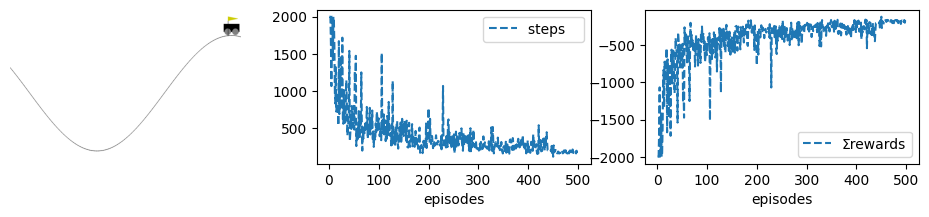

In [27]:
sarsa = Sarsa(env=GymDiscretised(**MountainCar), α=.1/1,  ε=0,  episodes=500, seed=1, **demoGym).interact()

In the above, we ran a Tabular SARSA, on the GymDiscretised Mountain Car environment. We can also use the vectorised form  vGymDiscretised, which uses one-hot encoding similar to what we did between the Grid and vGrid.

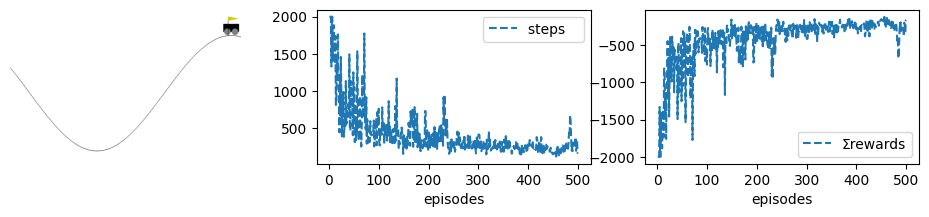

In [28]:
vsarsa = vSarsa(env=vGymDiscretised(**MountainCar), α=.1/1,  ε=0,  episodes=500, seed=1, **demoGym).interact()

## Gym Runs
Let us now develop a function to run several trials on a Gym environment to see how different state representations perform with varying learning rates.

In [1]:
from env.gym.discretised import *
from rl.linear import *

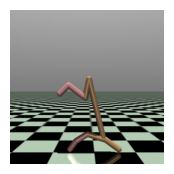

(100,)

In [2]:
env = GymDiscreteS(**HalfCheetah)
obs = play(env, 100, cont_actions=True)
np.array(obs).shape

In [2]:
'''
# A little utility to create a modified copy of any environment dictionary.
# Changes are temporary (per-experiment) by default — the original dict is never mutated.
# To permanently change a config, edit the source dictionary directly and document the change in your notebook.
'''
def envDict(base, **kw):
    return {**base, **kw}

# Examples:
# envDict(CartPole, n_bins=(1, 1, 6, 12))                          # focus bins on pole only
# envDict(CartPole, n_tiles=(6, 6, 8, 12), hash_size=2**15)        # tile coding tweaks
# envDict(MountainCar, n_tilings=16, hash_size=2**15)              # more tilings

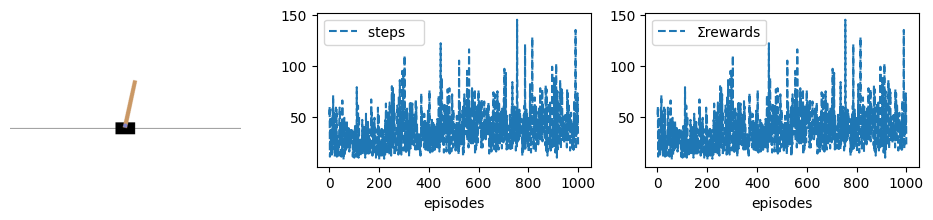

In [3]:
CartP = envDict(CartPole, n_bins=(2, 2, 8, 16))
vsarsa = vSarsa(env=vGymDiscreteS(**CartP), α=.08, ε=0.3, εT=100000, εmin=0, episodes=1000, seed=1, **demoGym).interact()

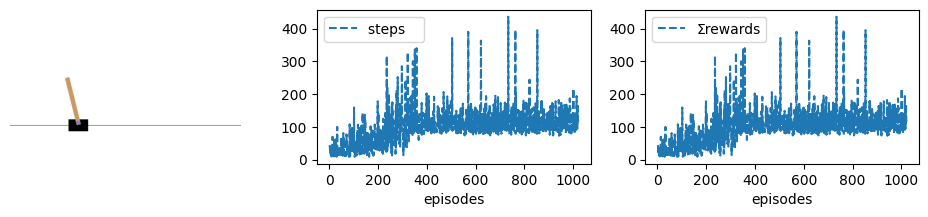

In [31]:
vsarsa.episodes=1020
vsarsa.interact(resume=True)
# vsarsa.Ts[1:700].sum()

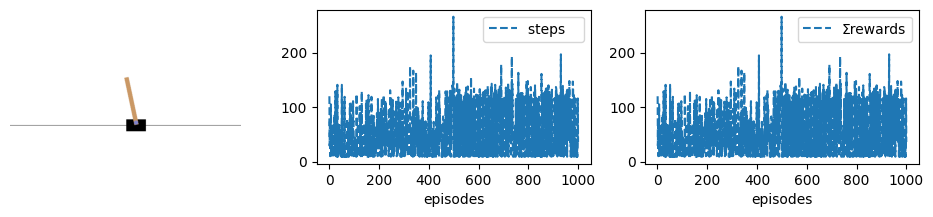

In [14]:
CartP = envDict(CartPole, n_bins=(1, 1, 8, 16))
vsarsa = vSarsa(env=vGymDiscreteS(**CartP), α=.1, ε=0.1, εT=5000, max_t=10000, episodes=1000, seed=1, **demoGym).interact()

401615

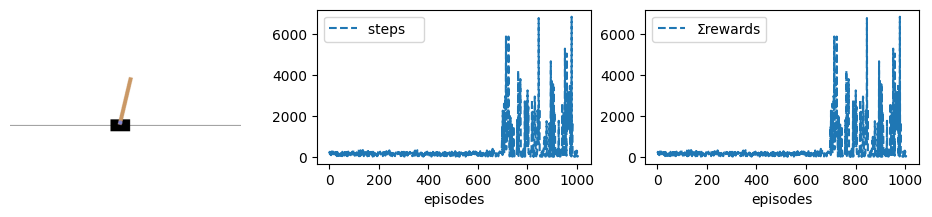

In [13]:
vsarsa.episodes=1005
vsarsa.interact(resume=True)
vsarsa.t_

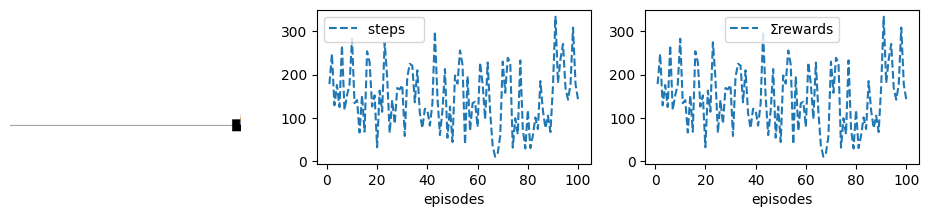

In [5]:
CartP = envDict(CartPole, n_bins=(1, 1, 8, 24))
vsarsa = vSarsa(env=vGymDiscreteS(**CartP), α=.3, ε=0.1, εT=500, max_t=10000, episodes=100, seed=1, **demoGym).interact()

> **Why discretisation struggles with CartPole**
> 
> CartPole balance is critically sensitive to small differences in pole angle and angular velocity —
> the agent must react before the pole tilts beyond ~12°. A coarse discrete grid cannot capture these
> fine-grained distinctions, so the agent learns a policy that works for some bins but fails for
> neighbouring ones, producing the zigzagging reward curve we observe.
>
> MountainCar does not have this problem because its reward landscape is smooth and slow-changing —
> coarse bins are sufficient to learn the momentum-building strategy.
>
> The natural fix is tile coding, which generalises across overlapping grids and provides the fine
> resolution CartPole needs without an explosion in state space. Discretisation is included here
> purely for comparison — to motivate why we move to function approximation.

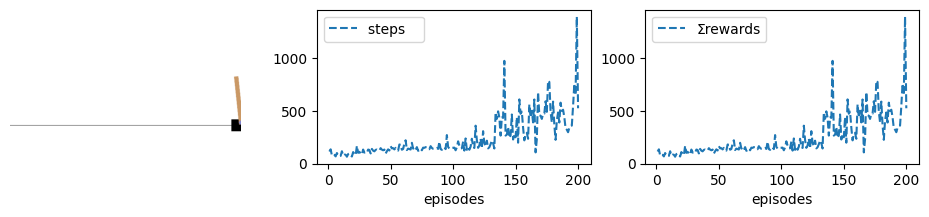

In [2]:
vsarsa = vSarsa(env=GymTiled(**CartPole), α=.3/8, ε=0.05, max_t=10000, episodes=200, seed=1, **demoGym).interact()

In [7]:
def algoGymRuns(runs=5, algo=vSarsa, env=vGymDiscreteS(**CartPole), αs=[.1, .2, .5], αscale=1.0, ε=0.05, episodes=200,
                label='discretised', ylog=True, ylim=None):  
    for α in αs:                                                                     
        sarsaRuns = Runs(algorithm=algo(env=env, α=α/αscale, episodes=episodes, ε=ε),
                         runs=runs, seed=1, plotT=True).interact(label=f'α = {α}/{αscale}')
    if ylog: plt.yscale('log')
    if ylim: plt.ylim(ylim)
    plt.title('Semi Gradient ' + algo.__name__ + ' on ' + env.spec.id + ' ' + label)

fig_10_2 = algoGymRuns

100%|██████████████████████████████████████████████████████████████████████████████████████████|5/5
100%|██████████████████████████████████████████████████████████████████████████████████████████|5/5


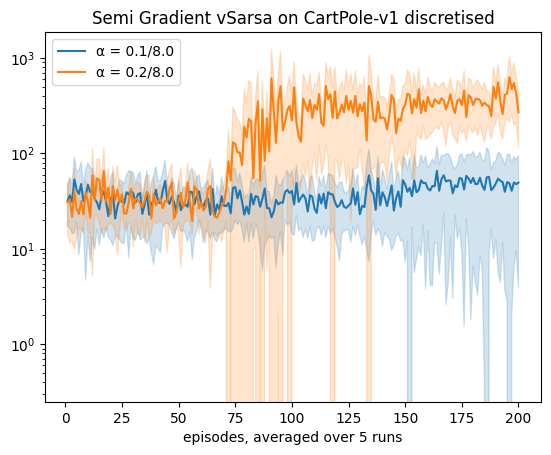

In [8]:
algoGymRuns(env=GymTiled(**CartPole), αscale=8.0, αs=[.1, .2, .3], ylog=True) # the longer the better

100%|██████████████████████████████████████████████████████████████████████████████████████████|5/5
100%|██████████████████████████████████████████████████████████████████████████████████████████|5/5
100%|██████████████████████████████████████████████████████████████████████████████████████████|5/5
CPU times: user 2min 1s, sys: 559 ms, total: 2min 2s
Wall time: 2min 1s


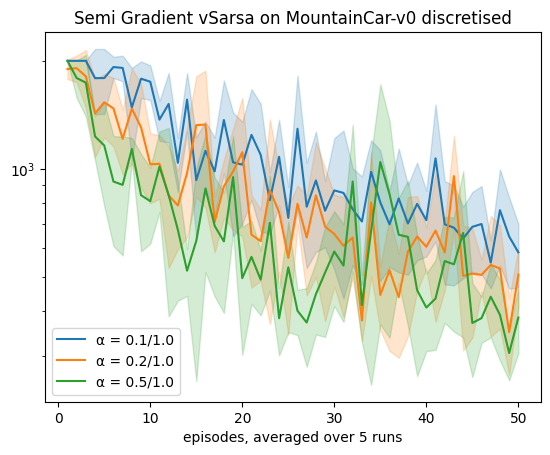

In [11]:
%time algoGymRuns(env=vGymDiscreteS(**MountainCar)) # the shorter the better

As we can see, the algorithm shows some signs of underperformance and instability. This is a common problem when we have less representational capabilities in our state space due to the additivity nature of our space.

The adopted additive representation is ok, but it has its limitations. The main issue is that the total number of possible states is $ntiles \times ntiles$, but the dimensionality of our vector is far less than that it is ntiles+ntiles. It is not a one-hot encoding, so each component does not correspond to one state. Instead, two components correspond to one state. These two issues combined reduced the capability of our algorithms to generalise to nearby states.

## Tile Coded State Representation (Multiplicative) with Hashing

We now switch to `GymTiled`, which handles tile coding and hashing automatically. Instead 
of two separate 1D encodings, it covers the **joint** position-velocity space with a 2D 
grid — capturing the interaction between the two dimensions — and repeats this grid 
$n_{tilings}$ times with small offsets to enrich the representation.

> **`GymTiled`** wraps a Gym environment with hashed tile coding. For each observation it 
> activates exactly $n_{tilings}$ components — one per tiling — producing a multi-hot feature 
> vector $\mathbf{x}(s) \in \mathbb{R}^{\text{hash\_size}}$. The fixed `hash_size` bounds 
> memory and computation regardless of the number of tilings.

Think of it like measuring with $n_{tilings}$ rulers laid side by side, each shifted by a 
fraction of a tile width. For any state, each ruler lights up exactly one tile — giving 
$n_{tilings}$ active components in total. The offsets are made asymmetric between position 
and velocity to improve generalisation.

### Hashing

Without hashing, the feature vector would grow as $n_{tiles} \times n_{tiles} \times 
n_{tilings}$, quickly becoming intractable. Hashing fixes the feature vector size at 
`hash_size` regardless — by mapping the tile indices $(i_{pos},\ i_{vel},\ i_{tiling})$ 
to a single index via a hash function, then taking the modulus with `hash_size`.

The key property is that the **same state always maps to the same index** — so learning 
is consistent. The only cost is occasional **collisions**, where two different states map 
to the same index. In practice this is negligible provided `hash_size` is large enough, 
since early in training the agent visits a small fraction of states, and collisions only 
become significant for rarely visited states once the table fills up.

In [ ]:
from env.gym.tiled import *

In [ ]:
mcar_tiled = GymTiled(**MountainCar)
n_tilings = MountainCar['n_tilings']
sarsa = vSarsa(env=mcar_tiled, α=.5/n_tilings, episodes=50, seed=1, ε=0, **demoGym).interact()

In [ ]:
from tqdm import trange

In [ ]:
def algoGymTiled(algo=vSarsa, envDict=MountainCar, n_tilings=8, ε=0):
    
    alg = algo(env=GymTiled(**{**envDict, 'n_tilings': n_tilings}), # change n_tilings in temp dict instead of permanently
                    α=.5/n_tilings, 
                    ε=ε, 
                    episodes=50, 
                    seed=1).interact()
    plt.plot(alg.Ts, '--',label='ntilings=%d'%n_tilings)
    plt.legend()

for n in trange(2,5):
    algoGymTiled(n_tilings=2**n)

plt.gcf().set_size_inches(20,4)
plt.ylim(100,2000)
plt.show()

Note the difference between the max steps and the max steps when we did not use tile coding. We will demonstrate the  advantage of tile coding further in a more extensive experiments.

### Tiled coded mountain car runs
Let us see how the new tile coding behaves with respect to different learning rates, to do we simply call the SarsaMCar() function but we pass the tiledMountainCar environment with n=8.


In [ ]:
algoGymRuns(runs=10, algo=vSarsa, env=GymTiled(**MountainCar), αscale=MountainCar['n_tilings'], label='with 8 tilings', ε=0)

Note that since we set  ε=0 and used optimistically initialisation, these settings made Sarsa closer to Q-learning in the sense that it is learning about a purely greedy policy (of course Q-learning is acting usually according to an exploratory policy  ε-greedy). Let us see how Q-learning behaves if we also set ε=0.

In [ ]:
algoGymRuns(runs=10, algo=vQlearn, env=GymTiled(**MountainCar), αscale=MountainCar['n_tilings'], label='with 8 tilings', ε=0)

Indeed as we can see .5/8 seems to be performing best for a additive one tile coding (the above class implemented one-hot coding which is a special case of tile coding where n=1). In the next section we implement a more generic state representation that allows for multiple tilings.

Reduce the hash table size (i.e. the number of features) used to represent *a state*. Once we have less representation power, we expect performance to deteriorate. Note that we are still dealing with 8x8x8 tiled coding; we are reducing the hash table's capacity to accommodate all discretised states without collisions.

In [ ]:
def creatGyTiled(envDict=MountainCar, n_tilings=16, n_tiles=(16, 16), hash_size=8*8*8):
    return GymTiled(**{**envDict, 'n_tilings': n_tilings, 'n_tiles': n_tiles, 'hash_size': hash_size})

hash_size = 8*16*16
algoGymRuns(runs=2, algo=vQlearn, env=creatGyTiled(hash_size=hash_size), αscale=16, label=f'with {hash_size} hash', ε=0)

As we can see the performance of the model deteriorated a bit when we reduced the hash table size due to collision.

## Tilings Comparison
In this section we compare between the performance of Sarsa on different tilings to see the effect of changing the power of state representation.

In [ ]:
def GymTiledTilings(runs=20, α=.3, algo=vSarsa, Env=GymTiled, envDict=MountainCar, tilings=[2, 4, 8, 16, 32]):
    plt.title('%s on %s: comparison of different tilings with α=%.2f/n_tilings'%(algo.__name__, envDict['env_id'], α))
    for n_tilings in tilings:
        sarsaRuns = Runs(algorithm=algo(env=Env(**{**envDict, 'n_tilings': n_tilings}),
                                        α=α/n_tilings, episodes=500, ε=0), 
                         runs=runs, seed=1, plotT=True).interact(label='%d tilings'%n_tilings)
    plt.ylim((10**2, 10**3))
    plt.yscale('log')
    plt.show()

In [ ]:
def MountainCarTilings(runs=20, α=.3, algo=Sarsa, env=tiledMountainCar):
    
    plt.title('Sarsa on mountain car: comparison of different tilings with α=%.2f/8'%α)
    for ntilings in [2, 4, 8, 16, 32]:
        sarsaRuns = Runs(algorithm=algo(env=env(ntiles=8, ntilings=ntilings),α=α/ntilings,episodes=500, ε=0), 
                         runs=runs, seed=1, plotT=True).interact(label='%d tilings'%ntilings)
    plt.ylim((10**2,10**3))
    plt.yscale('log')
    plt.show()

In [ ]:
GymTiledTilings()

## Comparing n-Step Sarsa on Mountain Car with different  α
Let us compare systematically how different number of steps plays with the learning rate α for the mountain car problem. We will use hashed tilings with 8 tiles and 8 tilings. The goal is to confirm whether the behaviour of n-step Sarsa for control is compatible with the behaviour of n-step TD for prediction. 

Below we show the implementation of n-step Sarsa with function approximation. It is identical to the tabular form except we use the function Q(sn,an) instead of Q[sn,an].

In [ ]:
class Sarsan(vMDP):

    def init(self):
        self.store = True        # although online but we need to access *some* of earlier steps,
        self.step = self.step_an # for Sarsa we want to decide the next action in time step t

    # ----------------------------- 🌖 online learning ----------------------    
    def online(self, *args):
        τ = self.t - (self.n-1);  n=self.n
        if τ<0: return
        
        # we take the min so that we do not exceed the episode limit (last step+1)
        τ1 = τ+1
        τn = τ+n ; τn=min(τn, self.t+1 - self.skipstep)
        
        sτ = self.s[τ];  aτ = self.a[τ]
        sn = self.s[τn]; an = self.a[τn]
        done = self.done[τn]
        
        # n steps τ+1,..., τ+n inclusive of both ends
        self.W[aτ] += self.α*(self.G(τ1,τn) + (1-done)*self.γ**n *self.Q(sn,an) - self.Q(sτ,aτ))*self.ΔQ(sτ)

Below we see that the an intermediate n (number of steps in n-step Sarsa) acts best in similar to the effect of the number of steps on random walk and that control algorithms with intermediate bootstrapping usually performs best.

In [ ]:
def MountainCarTiledRuns_n(runs=20, algo=Sarsan, env=tiledMountainCar):
    
    plt.title(algo.__name__+' on mountain car: comparison of n-steps with the same 8x8x8 tilings')
    for n, α in zip([1, 8], [.5, .3]):
        sarsaRuns = Runs(algorithm=algo(env=env(ntiles=8, ntilings=8), n=n, α=α/8,episodes=500, ε=0), 
                         runs=runs, seed=1, plotT=True).interact(label='%d step-Sarsa, α=%.2f/8'%(n,α))
    plt.ylim((10**2,10**3))
    plt.yscale('log')
    plt.show()
figure_10_3_n = MountainCarTiledRuns_n

In [ ]:
%time figure_10_3_n(env=tiledMountainCar)

In [ ]:
%time figure_10_3_n(env=hashedtiledMountainCar)

In [ ]:
%time figure_10_3_n(env=IHTtiledMountainCar)

As we can see the IHT performed exactly the same as the tiledMountainCar representation since we are using a large enough table_size, it gave a boost to the one-step Sarsa to become closer to the 8-step Sarsa.

### Model Selection for n_step Sarsa
In this section we conduct an extensive set of experiments on Mountain Car with different learning rates in a similar manner to the study that we conducted for TD with random walk problem.


In [ ]:
def MountainCarTiledCompare_n(runs=5, ntilings=8,  env=IHTtiledMountainCar): # 10
    
    xsticks = np.array([0, .5 , 1, 1.5, 2, 2.3])/ntilings
    plt.xticks(ticks=xsticks, labels=xsticks*ntilings)
    plt.yticks([220, 240, 260, 280, 300])
    plt.ylim(210, 300)
    plt.title('Steps per episode averaged over first 50 episodes')

    for n in range(5):
        if n==0: αs = np.arange(.4,  1.8,  .1)
        if n==1: αs = np.arange(.2,  1.8,  .1)
        if n==2: αs = np.arange(.1,  1.8,  .1)
        if n==3: αs = np.arange(.1,  1.2,  .07)
        if n==4: αs = np.arange(.1,  1.0,  .07)
    
        Compare(algorithm=Sarsan(env=env(ntiles=8, ntilings=ntilings), n=2**n, episodes=50, ε=0), runs=runs, 
                                  hyper={'α':αs/ntilings}, 
                                  plotT=True).compare(label='%d-step Sarsa'%2**n)
    plt.xlabel(r'$\alpha \times 8$ since we used 8 tiles for each tilings')
    plt.show()
    

figure_10_4_n = MountainCarTiledCompare_n

Note that we always divided the learning rates αs by ntilings to match the amount of changes for different number of tilings so that we end up with an update magnitude that is compatible with a one-hot encoding.

In [ ]:
%time MountainCarTiledCompare_n()

Note that we have not used hashing and hence our range is different from the one stated in the book. Nevertheless, the pattern is maintained.

## Conclusion
In this lesson, you saw how to deal with a continuous state space using function approximation and how to apply previous concepts to a more difficult control problem. We saw how to apply the tile coding technique we covered in the previous lesson on a continuous *control* Mountain car task. Along the way, we developed a new binary algorithm, Binary Sarsa, that is suitable for dealing with binary encoding, and we will study its performance. We present three representations of the problem. The first just discretised the space and used a vector representation that corresponds with this discretisation. This representation is equivalent to using one tiling in tile coding. Then we developed this representation to use multiple tiling that offset each other to enrich the representation capability for our continuous space. We then reduced the extra overhead introduced by the tile coding using hashing. We show that hashing is a powerful technique, and we studied a simple and efficient implementation of it. We concluded by updating our Sarsa(n) algorithm and applying it to the mountain car to compare its performance with different n. In the next lesson, we will show a new set of algorithms that achieve a similar or better performance without waiting for n steps.

## Your turn
1. run the MountainCarTilings but this time fixed the divider on 8 (instead of dividing by ntilings), observe the results and compare them to the original experiments, post what you can infer in the group discussion.



## Challenge
1. Implement a state rep that directly use the software library provided by the book [here]((http://incompleteideas.net/tiles/tiles3.py-remove)).
1. Can you think of a way to make the Mountain Car class works for the tabular case(assume that we have one tiling )

[Back to TOC](IntroductionTOC.ipynb)